# TSP Optimization with Simulated Annealing and Genetic Algorithms — Assignment Notebook

Works in **Jupyter** and **Google Colab**.

## Overview
You will solve the same TSP instance using **two heuristic optimization methods**:

1. **Simulated Annealing (SA)** with a 2-opt neighborhood  
2. **Genetic Algorithm (GA)** on **permutation tours** (a standard evolutionary approach for TSP)

The notebook provides:
- A reproducible TSP instance generator
- Tour utilities (length, validity)
- A 2-opt neighborhood operator
- Visualization helpers (tour plot + history plot)
- Baseline heuristic: nearest neighbor

## Tasks
### Task A — Simulated Annealing (SA)
Implement `simulated_annealing_tsp(...)`.

### Task B — Genetic Algorithm (GA)
Implement `genetic_algorithm_tsp(...)` plus helper functions:
- Tournament selection
- Order crossover (OX)
- Swap mutation

## Deliverables
- Completed notebook (or exported `.py`) (find all TODOs and implement them)
- Short write-up (more detail in Part 6):
  - SA parameters + best length
  - GA parameters + best length
  - Brief comparison: which worked better and why

---


In [1]:
# If running in a fresh environment, uncomment as needed:
# !pip -q install matplotlib

import math
import random
from dataclasses import dataclass
from typing import List, Tuple

import matplotlib.pyplot as plt


## Part 1 — TSP utilities (provided)

In [2]:
Point = Tuple[float, float]
Tour = List[int]

def make_cities(n: int = 40, seed: int = 7) -> List[Point]:
    # Reproducible 2D city coordinates in [0, 1]x[0, 1].
    rng = random.Random(seed)
    return [(rng.random(), rng.random()) for _ in range(n)]

def dist(a: Point, b: Point) -> float:
    dx = a[0] - b[0]
    dy = a[1] - b[1]
    return math.hypot(dx, dy)

def tour_length(cities: List[Point], tour: Tour) -> float:
    # Total length of a closed tour.
    n = len(tour)
    total = 0.0
    for i in range(n):
        total += dist(cities[tour[i]], cities[tour[(i + 1) % n]])
    return total

def is_valid_tour(tour: Tour, n: int) -> bool:
    return len(tour) == n and set(tour) == set(range(n))

def random_tour(n: int, rng: random.Random) -> Tour:
    t = list(range(n))
    rng.shuffle(t)
    return t

def nearest_neighbor_tour(cities: List[Point], start: int = 0) -> Tour:
    # Deterministic baseline: greedy nearest neighbor.
    n = len(cities)
    unvisited = set(range(n))
    tour = [start]
    unvisited.remove(start)
    cur = start
    while unvisited:
        nxt = min(unvisited, key=lambda j: dist(cities[cur], cities[j]))
        tour.append(nxt)
        unvisited.remove(nxt)
        cur = nxt
    return tour


## Part 2 — Neighborhood operator (2-opt) (provided)

In [3]:
def two_opt_swap(tour: Tour, i: int, k: int) -> Tour:
    # Return a new tour where the segment [i:k] is reversed.
    return tour[:i] + list(reversed(tour[i:k + 1])) + tour[k + 1:]

def random_two_opt_neighbor(tour: Tour, rng: random.Random) -> Tour:
    # Pick a random 2-opt move.
    n = len(tour)
    i = rng.randrange(0, n - 1)
    k = rng.randrange(i + 1, n)
    return two_opt_swap(tour, i, k)


## Part 3 — Visualization helpers (provided)

* You are encouraged to implement more variations of visualization.

In [4]:
def plot_tour(cities: List[Point], tour: Tour, title: str = "") -> None:
    xs = [cities[i][0] for i in tour] + [cities[tour[0]][0]]
    ys = [cities[i][1] for i in tour] + [cities[tour[0]][1]]

    plt.figure(figsize=(6, 6))
    plt.plot(xs, ys, marker="o")
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.gca().set_aspect("equal", adjustable="box")
    plt.show()

def plot_history(series: List[float], title: str, ylabel: str = "Value") -> None:
    plt.figure(figsize=(7, 4))
    plt.plot(series)
    plt.title(title)
    plt.xlabel("Iteration")
    plt.ylabel(ylabel)
    plt.show()

def plot_compare(sa_hist: List[float], ga_hist: List[float]) -> None:
    # Overlay histories (x-axis is not identical meaning; this is a visual comparison).
    plt.figure(figsize=(8, 4))
    plt.plot(sa_hist, label="SA best-so-far")
    plt.plot([i * (len(sa_hist) / max(1, len(ga_hist)-1)) for i in range(len(ga_hist))], ga_hist, label="GA best-by-gen")
    plt.title("SA vs GA: Best tour length over time (scaled x-axis)")
    plt.xlabel("Progress (scaled)")
    plt.ylabel("Length")
    plt.legend()
    plt.show()


## Part 4 — Baseline tour (nearest neighbor) (provided)

Nearest-neighbor length: 6.0214


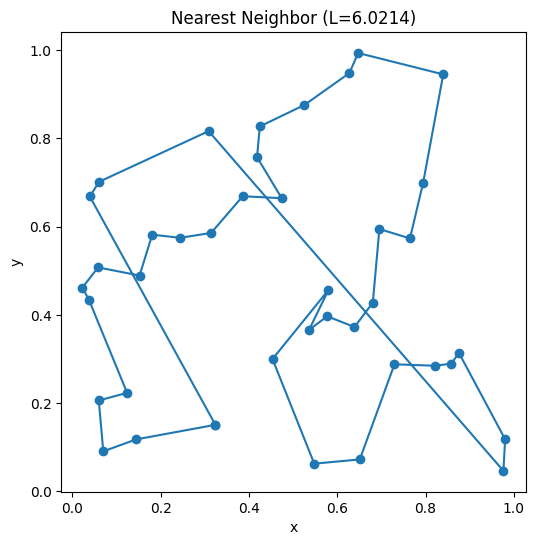

In [5]:
cities = make_cities(n=40, seed=7)

nn_tour = nearest_neighbor_tour(cities, start=0)
nn_len = tour_length(cities, nn_tour)
print(f"Nearest-neighbor length: {nn_len:.4f}")

plot_tour(cities, nn_tour, title=f"Nearest Neighbor (L={nn_len:.4f})")


# Part 5A — Code Skeleton: Simulated Annealing (SA)

Complete `simulated_annealing_tsp(...)`.

### SA acceptance rule
Let `delta = cand_len - cur_len`.
- If `delta <= 0`, accept.
- Else accept with probability `exp(-delta / T)`.

### Cooling schedule
Geometric cooling:
- `T = T * alpha` each iteration
- clamp `T = max(T, 1e-12)`


In [6]:
@dataclass
class SAConfig:
    iters: int = 20_000
    t0: float = 0.2
    alpha: float = 0.9995
    seed: int = 123
    report_every: int = 2000

def simulated_annealing_tsp(cities: List[Point], init_tour: Tour, cfg: SAConfig) -> Tuple[Tour, float, List[float]]:
    rng = random.Random(cfg.seed)
    n = len(cities)
    assert is_valid_tour(init_tour, n), "init_tour must be a valid permutation"

    cur_tour = init_tour[:]
    cur_len = tour_length(cities, cur_tour)

    best_tour = cur_tour[:]
    best_len = cur_len
    history = [best_len]

    T = cfg.t0

    for it in range(cfg.iters):
        cand_tour = random_two_opt_neighbor(cur_tour, rng)
        cand_len = tour_length(cities, cand_tour)
        delta = cand_len - cur_len

        accept = False
        # DONE: acceptance rule
        # Accept is True when delta <= 0
        if delta <= 0:
            accept = True
        else: #set probability of accepting, controled by cooling schedule
            accept = math.exp(-delta / T) > rng.random()

        if accept: #save current length as new candiate lengths
            cur_tour, cur_len = cand_tour, cand_len

        if cur_len < best_len: #compare with best path found so far
            best_tour, best_len = cur_tour[:], cur_len

        history.append(best_len) #add best_length found to saved history

        # TODO: cooling schedule
        # T starts at less than one and continues to lower/cool by very small increments
        # T never hits 0
        T = T * cfg.alpha
        T = max(T, 1e-15)

        if cfg.report_every and (it + 1) % cfg.report_every == 0:
            print(f"[SA] iter={it+1:6d}  T={T:.4g}  cur={cur_len:.4f}  best={best_len:.4f}")

    return best_tour, best_len, history


## Run SA (after you implement it)

[SA] iter=   500  T=0.1558  cur=10.7122  best=6.0214
[SA] iter=  1000  T=0.1213  cur=8.7667  best=6.0214
[SA] iter=  1500  T=0.09446  cur=7.9573  best=6.0214
[SA] iter=  2000  T=0.07356  cur=8.3800  best=6.0214
[SA] iter=  2500  T=0.05728  cur=7.3791  best=6.0214
[SA] iter=  3000  T=0.04461  cur=6.7793  best=6.0214
[SA] iter=  3500  T=0.03474  cur=6.5801  best=6.0214
[SA] iter=  4000  T=0.02705  cur=6.5972  best=6.0214
[SA] iter=  4500  T=0.02107  cur=5.9446  best=5.9446
[SA] iter=  5000  T=0.01641  cur=5.5555  best=5.5555
[SA] iter=  5500  T=0.01278  cur=5.3562  best=5.3562
[SA] iter=  6000  T=0.00995  cur=5.3139  best=5.3139
[SA] iter=  6500  T=0.007749  cur=5.2067  best=5.2067
[SA] iter=  7000  T=0.006034  cur=5.0057  best=5.0057
[SA] iter=  7500  T=0.004699  cur=5.0057  best=5.0057
[SA] iter=  8000  T=0.003659  cur=5.0057  best=5.0057
[SA] iter=  8500  T=0.00285  cur=5.0057  best=5.0057
[SA] iter=  9000  T=0.002219  cur=5.0057  best=5.0057
[SA] iter=  9500  T=0.001728  cur=5.0057  

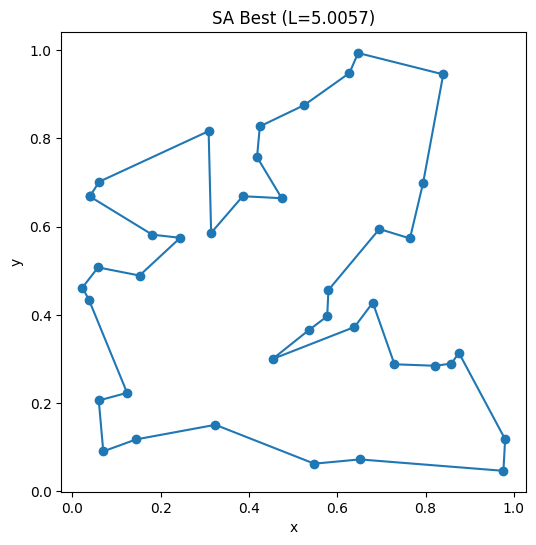

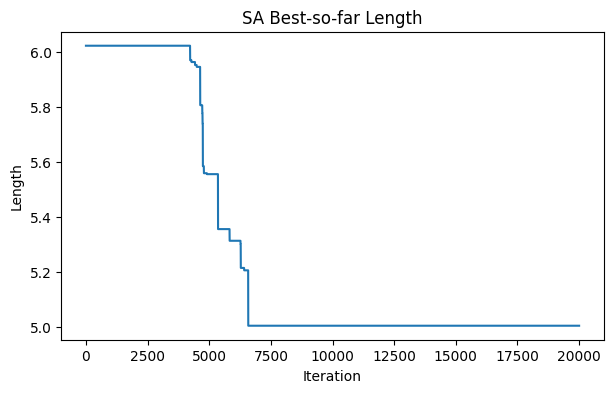

In [41]:
sa_cfg = SAConfig(iters=20_000, t0=0.2, alpha=0.9995, seed=123, report_every=500)
sa_best_tour, sa_best_len, sa_hist = simulated_annealing_tsp(cities, nn_tour[:], sa_cfg)

print(f"SA best length: {sa_best_len:.4f}")
print(f"SA improvement vs NN: {(nn_len - sa_best_len) / nn_len * 100:.2f}%")

assert is_valid_tour(sa_best_tour, len(cities))

plot_tour(cities, sa_best_tour, title=f"SA Best (L={sa_best_len:.4f})")
plot_history(sa_hist, title="SA Best-so-far Length", ylabel="Length")


# Part 5B — Code Skeleton: Genetic Algorithm (GA) for TSP

Implement a GA that evolves a population of permutation tours.

You will implement:
- `tournament_select(...)`
- `order_crossover_ox(...)` (Order Crossover)
- `mutate_swap(...)`
- `genetic_algorithm_tsp(...)`


In [8]:
@dataclass
class GAConfig:
    pop_size: int = 200
    generations: int = 400
    tournament_k: int = 5
    crossover_rate: float = 0.9
    mutation_rate: float = 0.6
    elite_size: int = 1
    seed: int = 999
    report_every: int = 50

def tournament_select(pop: List[Tour], lengths: List[float], k: int, rng: random.Random) -> Tour:
    # DONE: tournament selection (minimize length)
    # Co-Lab AI assisted in auto complete for some of the code
    k_indices = rng.sample(range(len(pop)), k) #generate random number of tours
    k_lengths = [lengths[i] for i in k_indices] #find length of tour
    min_idx = min(range(k), key=lambda i: k_lengths[i]) #select minium length
    return pop[k_indices[min_idx]][:]


def order_crossover_ox(parent1: Tour, parent2: Tour, rng: random.Random) -> Tour:
    # DONE: order crossover (OX)
    # Co-Lab AI assisted in auto complete for some of the code
    parent1_len = len(parent1)
    child = [None] * parent1_len
    start, end = sorted(rng.sample(range(parent1_len), 2))
    for i in range(start, end):     #copy slice selected
        child[i] = parent1[i]
    used = set(x for x in child if x is not None) #keep track cities from parent1
    order = list(range(end, parent1_len)) + list(range(0,end)) #start from end to wrap around
    empty_positions = [idx for idx in order if child[idx] is None] #fill remaining positions
    pos_ptr = 0 #point to first element
    for idx in order: #traverse list
      city = parent2[idx]
      if city not in used: #check for duplicate
        child[empty_positions[pos_ptr]] = city
        used.add(city) #mark city as used
        pos_ptr += 1   #advance pointing
    return child

def mutate_swap(tour: Tour, rng: random.Random) -> Tour:
    # DONE: swap mutation
    # Co-Lab AI assisted in auto complete for some of the code
    child = tour[:]                        #working copy of tour list
    i, k = rng.sample(range(len(tour)), 2) #random select indexes, i != k
    child[i], child[k] = child[k], child[i] #swap elements
    return child

def genetic_algorithm_tsp(cities: List[Point], init_seed_tours: List[Tour], cfg: GAConfig) -> Tuple[Tour, float, List[float]]:
    rng = random.Random(cfg.seed)
    n = len(cities)

    pop: List[Tour] = []
    for t in init_seed_tours:
        assert is_valid_tour(t, n)
        pop.append(t[:])
    while len(pop) < cfg.pop_size:
        pop.append(random_tour(n, rng))

    lengths = [tour_length(cities, t) for t in pop]
    best_idx = min(range(len(pop)), key=lambda i: lengths[i])
    best_tour = pop[best_idx][:]
    best_len = lengths[best_idx]
    history = [best_len]

    for gen in range(cfg.generations):
        elite_indices = sorted(range(len(pop)), key=lambda i: lengths[i])[: cfg.elite_size]
        next_pop = [pop[i][:] for i in elite_indices]

        while len(next_pop) < cfg.pop_size:
            p1 = tournament_select(pop, lengths, cfg.tournament_k, rng)
            p2 = tournament_select(pop, lengths, cfg.tournament_k, rng)

            if rng.random() < cfg.crossover_rate:
                child = order_crossover_ox(p1, p2, rng)
            else:
                child = p1[:]

            if rng.random() < cfg.mutation_rate:
                child = mutate_swap(child, rng)

            next_pop.append(child)

        pop = next_pop
        lengths = [tour_length(cities, t) for t in pop]

        gen_best_idx = min(range(len(pop)), key=lambda i: lengths[i])
        gen_best_len = lengths[gen_best_idx]
        if gen_best_len < best_len:
            best_len = gen_best_len
            best_tour = pop[gen_best_idx][:]

        history.append(best_len)

        if cfg.report_every and (gen + 1) % cfg.report_every == 0:
            print(f"[GA] gen={gen+1:4d}  best={best_len:.4f}")

    assert is_valid_tour(best_tour, n)
    return best_tour, best_len, history


## Run GA

* After you implement TODOs above
* This is just for your reference, you can experiment with different paramesters

[GA] gen=  50  best=5.1676
[GA] gen= 100  best=4.8529
[GA] gen= 150  best=4.8529
[GA] gen= 200  best=4.8326
[GA] gen= 250  best=4.8326
[GA] gen= 300  best=4.8326
[GA] gen= 350  best=4.8326
[GA] gen= 400  best=4.8326
[GA] gen= 450  best=4.8326
[GA] gen= 500  best=4.8326
[GA] gen= 550  best=4.8326
[GA] gen= 600  best=4.8326
[GA] gen= 650  best=4.8326
[GA] gen= 700  best=4.8326
[GA] gen= 750  best=4.8326
[GA] gen= 800  best=4.8326
[GA] gen= 850  best=4.8326
[GA] gen= 900  best=4.8326
[GA] gen= 950  best=4.8326
[GA] gen=1000  best=4.8326
GA best length: 4.8326
GA improvement vs NN: 19.74%


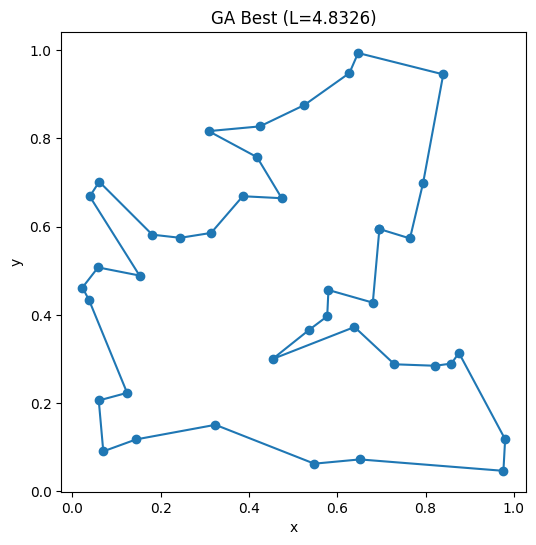

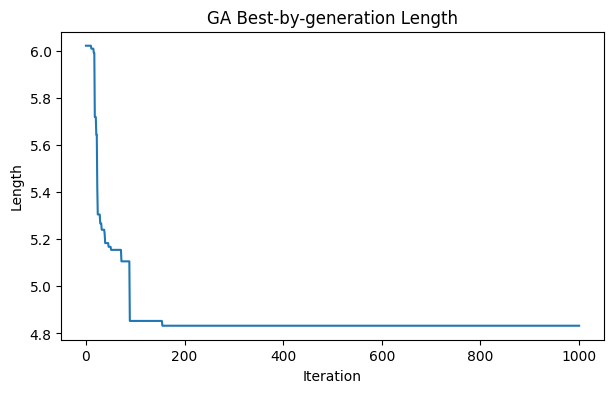

In [38]:
ga_cfg = GAConfig(pop_size=500, generations=1000, tournament_k=5, crossover_rate=0.9,
                   mutation_rate=0.6, elite_size=3, seed=999, report_every=50)
                    #mutatoin_rate tuned from 0.2 to create better diversity and improve best
ga_best_tour, ga_best_len, ga_hist = genetic_algorithm_tsp(cities, init_seed_tours=[nn_tour], cfg=ga_cfg)

print(f"GA best length: {ga_best_len:.4f}")
print(f"GA improvement vs NN: {(nn_len - ga_best_len) / nn_len * 100:.2f}%")

plot_tour(cities, ga_best_tour, title=f"GA Best (L={ga_best_len:.4f})")
plot_history(ga_hist, title="GA Best-by-generation Length", ylabel="Length")


# Part 6 — Data Collection, Visualization and Comparison

See Report PDF for comparison and visualization screenshots.

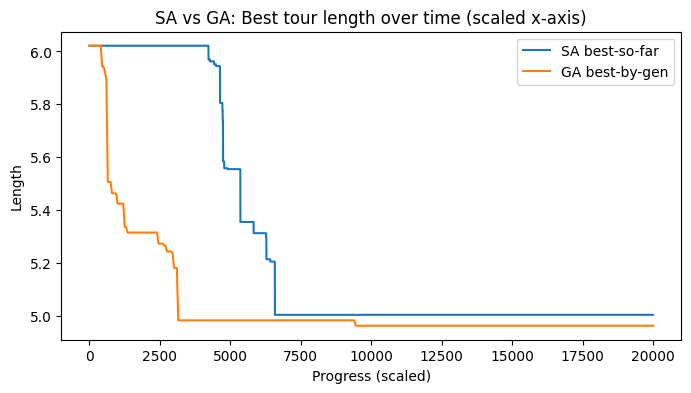

NN: 6.0214 | SA: 5.0057 | GA: 4.9646
SA length: 5.0057 | Improvement vs NN: 16.87%
✅ SA passed improvement threshold!
GA length: 4.9646 | Improvement vs NN: 17.55%
✅ GA passed improvement threshold!


In [12]:
# After both SA and GA work, run:
plot_compare(sa_hist, ga_hist)

# And print a quick summary:
print(f"NN: {nn_len:.4f} | SA: {sa_best_len:.4f} | GA: {ga_best_len:.4f}")

# TODO: Used provided functions for checking.
#runs function to check if improvement of the algorithms if over 10%
grade_check(nn_len, sa_best_len, min_improvement_pct=10.0, label="SA")
grade_check(nn_len, ga_best_len, min_improvement_pct=10.0, label="GA")


## Example of how to check your work

In [11]:
def grade_check(nn_len: float, method_len: float, min_improvement_pct: float = 10.0, label: str = "Method") -> None:
    improvement = (nn_len - method_len) / nn_len * 100.0
    print(f"{label} length: {method_len:.4f} | Improvement vs NN: {improvement:.2f}%")
    assert improvement >= min_improvement_pct, (
        f"{label} improvement {improvement:.2f}% is below required {min_improvement_pct:.2f}%"
    )
    print(f"✅ {label} passed improvement threshold!")


# Part 7: Optional Task

After tuning different parameters and analyzing the behavior of the Genetic Algorithm: I found that increasing the mutation rate from 0.2 to 0.6 increases its improvement to 17%. However, it does converge in very early generations still. The crossover rate at 0.9 seems to generate the best improvement with current parameters. However, adjusting mutation rate further to 0.8 fixes the early convergance in the 40th iteration and now converges in the much later, around the 300th iteration.